In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(291,495)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [7]:
helicity=[]
betacity=[]
coilcity=[]
for i in range(len(systems)):
    helicity.append(load(system_names[i]+"helicities.npy"))
    betacity.append(load(system_names[i]+"betacities.npy"))
    coilcity.append(load(system_names[i]+"coilcities.npy"))
    
allrmsfs_residue=[]
for i in range(len(systems)):
    allrmsfs_residue.append(load(system_names[i]+"rmsf.npy"))

In [4]:
avghelicities = []
avgbetacities = []
avgcoilcities = []
semhelicities = []
sembetacities = []
semcoilcities = []
for i in range(len(helicity)):
    avghelicities.append(mean(helicity[i],axis = 0))
    avgbetacities.append(mean(betacity[i],axis = 0))
    avgcoilcities.append(mean(coilcity[i],axis = 0))
    semhelicities.append(scipy.stats.sem(helicity[i],axis = 0))
    sembetacities.append(scipy.stats.sem(betacity[i],axis = 0))
    semcoilcities.append(scipy.stats.sem(coilcity[i],axis = 0))
    
def insertMyNans(huArray,indices):
    huList = list(huArray)
    for i in range(len(indices)):
        huList.insert(indices[i],nan)
    return array(huList)


(400.0, 440.0)

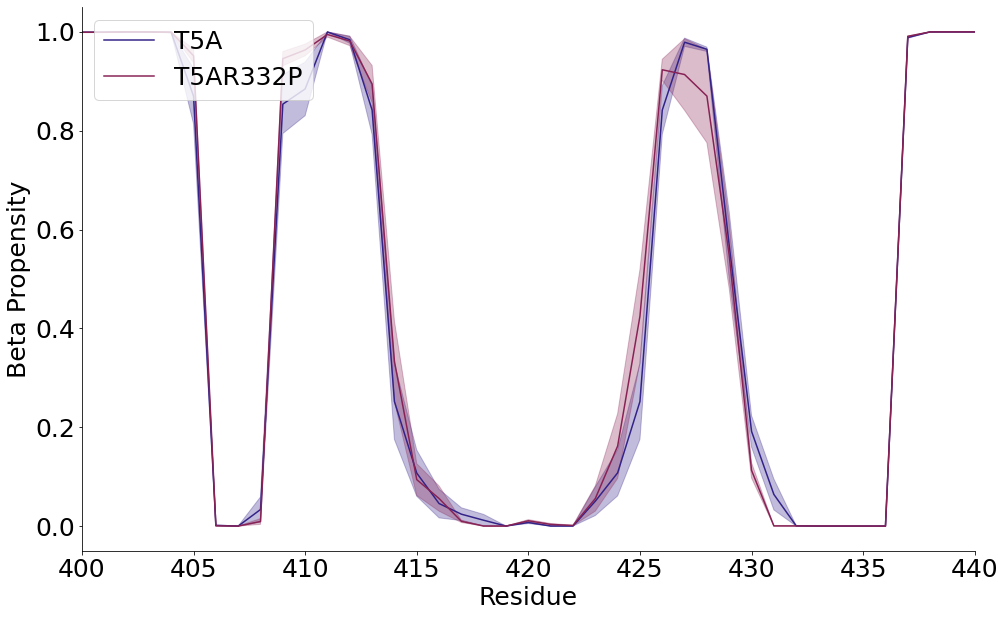

In [6]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False

figure(figsize = (16,10))
for i in range(1,3):#len(avghelicities)):
    
    plot(huresids,avgbetacities[i],color = colourScheme[i],label = system_names[i])
    fill_between(huresids, avgbetacities[i] - sembetacities[i],avgbetacities[i] + sembetacities[i],color = colourScheme[i],alpha = 0.3)

    
    
xlabel("Residue",fontsize = 25)
ylabel("Beta Propensity",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25,loc = "upper left")

#xlim(405,430)
#ylim(0,0.6)
#axvline(342)
xlim(400,440)

(400.0, 440.0)

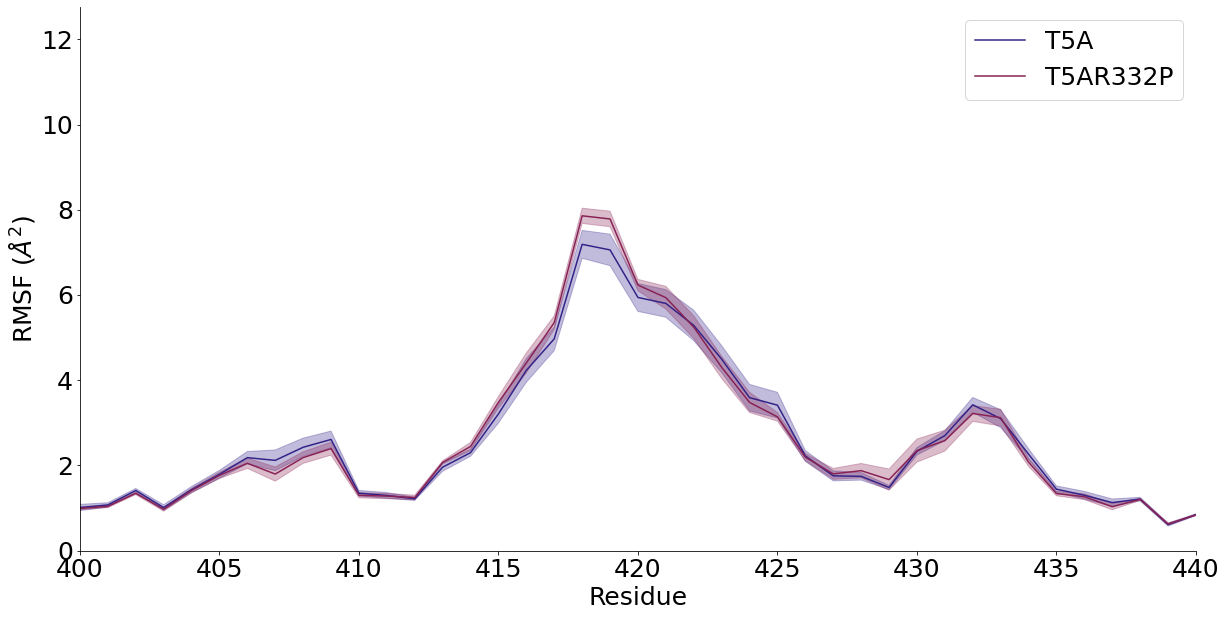

In [12]:
#allrmsfs_residue=load("allrmsfs_residue.npy",allow_pickle = True)
            
    
system_avg=[]
system_sem=[]

for i in range(len(allrmsfs_residue)):
    system_avg.append(mean(allrmsfs_residue[i],axis = 0))
    system_sem.append(scipy.stats.sem(allrmsfs_residue[i],axis = 0))
    
#def insertMyNans(huArray,indices):
#    huList = list(huArray)
#    # Note, index list should be in descending order, otherwise there will be problems 
#    # (since the index of later indexes will increase every time you make an insertion)
#    for i in range(len(indices)):
#        huList.insert(indices[i],nan)
#    return array(huList)
##
#for i in range(1,len(system_avg)):
#    system_avg[i] = insertMyNans(system_avg[i],indices = [338-290,338-290])
#    system_sem[i] = insertMyNans(system_sem[i],indices = [338-290,338-290])
    
    
    
rhresids = arange(291,495)
huresids = systems[1][0].select_atoms("protein").residues.resids
figure(figsize = (20,10))
#plot(rhresids,system_avg[0],color = colourScheme[0],label = system_names[0])
plot(huresids,system_avg[1],color = colourScheme[1],label = system_names[1])
plot(huresids,system_avg[2],color = colourScheme[2],label = system_names[2])
    
#fill_between(rhresids, system_avg[0] - system_sem[0],system_avg[0] + system_sem[0],color = colourScheme[0],alpha = 0.3)
fill_between(huresids, system_avg[1] - system_sem[1],system_avg[1] + system_sem[1],color = colourScheme[1],alpha = 0.3)
fill_between(huresids, system_avg[2] - system_sem[2],system_avg[2] + system_sem[2],color = colourScheme[2],alpha = 0.3)


xlabel("Residue",fontsize = 25)
ylabel("RMSF ($\AA^2$)",fontsize = 25)
xticks(fontsize = 25)
yticks(fontsize = 25)
legend(fontsize = 25)

#axvline(415,alpha = 0.1)
#xlim(400,440)
xlim(400,440)


